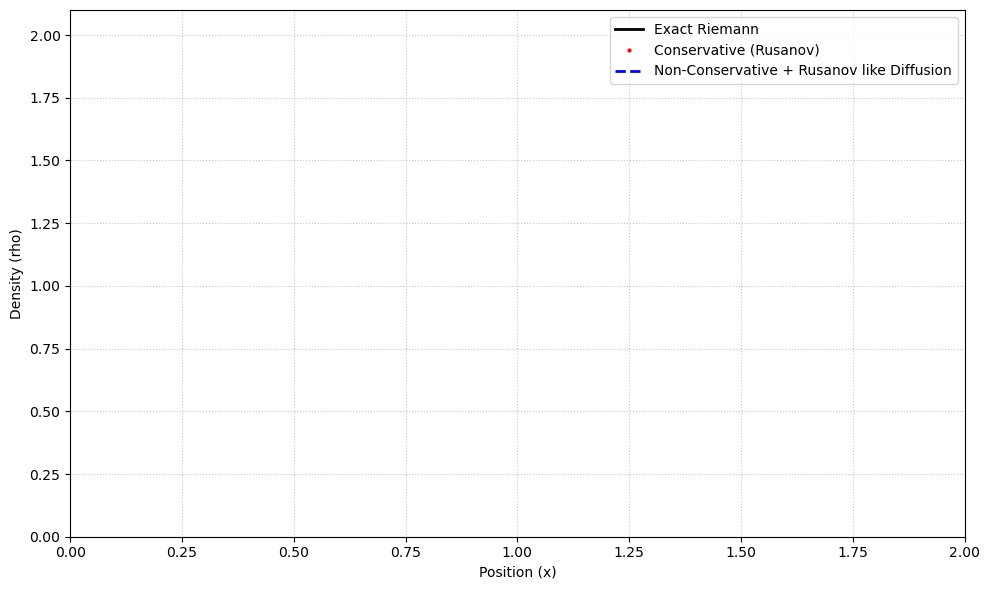

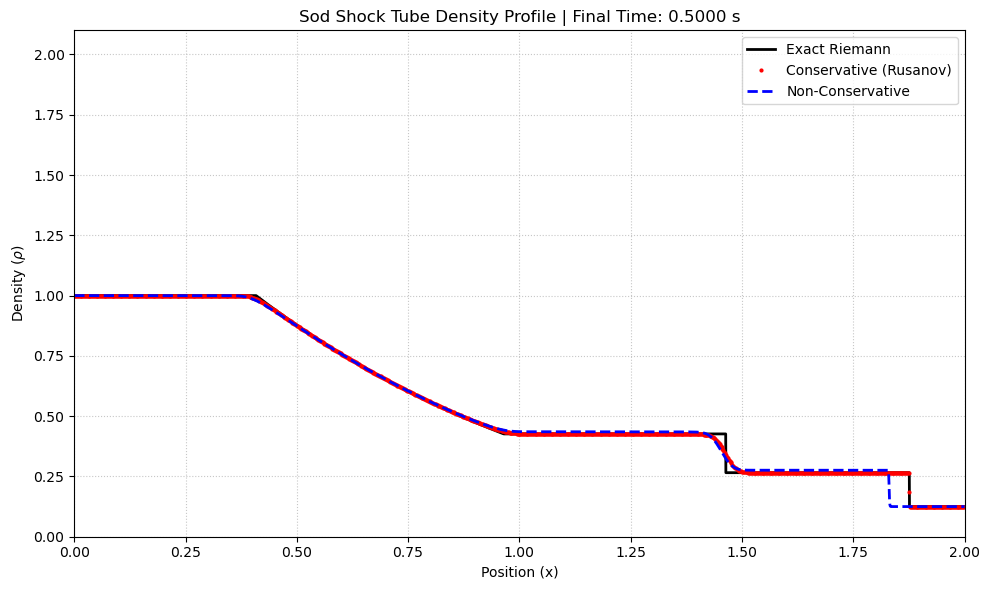

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.animation import FuncAnimation

# =========================================================
# Parameters
# =========================================================
gamma = 1.4
L = 2.0
Nx = 1000
x = np.linspace(0, L, Nx)
dx = x[1] - x[0]
T = 0.5
CFL = 0.5
x0 = 1.0

# =========================================================
# Initial Condition (Sod)
# =========================================================
rho0 = np.where(x < x0, 1.0, 0.125)
u0   = np.zeros_like(x)
p0   = np.where(x < x0, 1.0, 0.1)

# =========================================================
# Primitive → Conservative
# =========================================================
def prim_to_cons(rho, u, p):
    E = p/(gamma-1) + 0.5*rho*u**2
    return np.vstack((rho, rho*u, E)).T

def cons_to_prim(U):
    rho = U[:,0]
    u   = U[:,1]/rho
    E   = U[:,2]
    p   = (gamma-1)*(E - 0.5*rho*u**2)
    return rho, u, p

# =========================================================
# Exact Solution 
# =========================================================
def exact_sod(x, t, gamma=1.4):

    # Left and right states
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1

    if t == 0.0:
        rho = np.where(x < x0, rhoL, rhoR)
        u   = np.zeros_like(x)
        p   = np.where(x < x0, pL, pR)
        return prim_to_cons(rho, u, p)

    # Sound speeds
    cL = math.sqrt(gamma * pL / rhoL)
    cR = math.sqrt(gamma * pR / rhoR)

    # --- Solve for p_star using Newton iteration ---
    def f(p, rho, p0, c):
        if p > p0:  # shock
            A = 2 / ((gamma + 1) * rho)
            B = (gamma - 1) / (gamma + 1) * p0
            return (p - p0) * math.sqrt(A / (p + B))
        else:       # rarefaction
            return (2 * c / (gamma - 1)) * ((p / p0)**((gamma - 1)/(2*gamma)) - 1)

    def df(p, rho, p0, c):
        if p > p0:
            A = 2 / ((gamma + 1) * rho)
            B = (gamma - 1) / (gamma + 1) * p0
            return math.sqrt(A / (p + B)) * (1 - 0.5 * (p - p0)/(p + B))
        else:
            return (c / (gamma * p0)) * (p / p0)**(-(gamma + 1)/(2*gamma))

    # Initial guess (PVRS)
    p = max(1e-6, 0.5 * (pL + pR) - 0.125 * (uR - uL) * (rhoL + rhoR) * (cL + cR))

    for _ in range(20):
        p -= (f(p, rhoL, pL, cL) + f(p, rhoR, pR, cR) + uR - uL) / \
             (df(p, rhoL, pL, cL) + df(p, rhoR, pR, cR))

    p_star = p
    u_star = 0.5 * (uL + uR) + 0.5 * (f(p_star, rhoR, pR, cR) - f(p_star, rhoL, pL, cL))

    rho = np.zeros_like(x)
    u   = np.zeros_like(x)
    p   = np.zeros_like(x)

    for i in range(len(x)):
        xi = (x[i] - x0) / t

        if xi < u_star:
            # LEFT SIDE
            if p_star > pL:  # left shock (not in Sod)
                pass
            else:  # left rarefaction
                shl = uL - cL
                stl = u_star - math.sqrt(gamma * p_star / (rhoL * (p_star / pL)**(1/gamma)))

                if xi < shl:
                    rho[i], u[i], p[i] = rhoL, uL, pL
                elif xi < stl:
                    u[i] = (2/(gamma+1)) * (cL + xi)
                    c = cL - 0.5*(gamma-1)*u[i]
                    rho[i] = rhoL * (c/cL)**(2/(gamma-1))
                    p[i]   = pL * (c/cL)**(2*gamma/(gamma-1))
                else:
                    rho[i] = rhoL * (p_star/pL)**(1/gamma)
                    u[i]   = u_star
                    p[i]   = p_star
        else:
            # RIGHT SIDE
            if p_star > pR:  # right shock
                sr = uR + cR * math.sqrt((gamma+1)/(2*gamma)*(p_star/pR) + (gamma-1)/(2*gamma))
                if xi > sr:
                    rho[i], u[i], p[i] = rhoR, uR, pR
                else:
                    rho[i] = rhoR * ((p_star/pR + (gamma-1)/(gamma+1)) /
                                     ((gamma-1)/(gamma+1)*p_star/pR + 1))
                    u[i]   = u_star
                    p[i]   = p_star
            else:  # right rarefaction (not in Sod)
                pass

    return prim_to_cons(rho, u, p)

# =========================================================
# Shared Time Marching for Animation
# =========================================================

rho_rus = rho0.copy()
u_rus   = u0.copy()
p_rus   = p0.copy()

rho_non = rho0.copy()
u_non   = u0.copy()
p_non   = p0.copy()

t = 0.0

frames_rus = []
frames_non = []
frames_exact = []
time_list  = []


frames_rus.append(rho0.copy())
frames_non.append(rho0.copy())
U_exact_0 = exact_sod(x, 0.0, gamma)
rho_exact_0, _, _ = cons_to_prim(U_exact_0)
frames_exact.append(rho_exact_0)
time_list.append(0.0)

while t < T:

    # ---- Compute global dt (same for both schemes) ----
    a_rus = np.sqrt(gamma*p_rus/rho_rus)
    a_non = np.sqrt(gamma*p_non/rho_non)

    max_speed = max(
        np.max(np.abs(u_rus)+a_rus),
        np.max(np.abs(u_non)+a_non)
    )

    dt = CFL*dx/max_speed
    if t + dt > T:
        dt = T - t

    # =====================================================
    # ---- Rusanov Step ----
    # =====================================================
    U = prim_to_cons(rho_rus, u_rus, p_rus)

    rho, u, p = cons_to_prim(U)
    a = np.sqrt(gamma * p / rho) 

    F = np.zeros_like(U)
    F[:,0] = rho*u
    F[:,1] = rho*u**2 + p
    F[:,2] = (U[:,2]+p)*u

    F_half = np.zeros((Nx-1,3))

    for i in range(Nx-1):
        UL = U[i]
        UR = U[i+1]
        
        alpha = max(abs(u[i]) + a[i], abs(u[i+1]) + a[i+1])

        F_half[i] = 0.5*(F[i]+F[i+1]) - 0.5*alpha*(UR-UL)

    U_new = U.copy()
    for i in range(1,Nx-1):
        U_new[i] = U[i] - dt/dx*(F_half[i]-F_half[i-1])

    U_new[0] = U_new[1]
    U_new[-1] = U_new[-2]

    rho_rus, u_rus, p_rus = cons_to_prim(U_new)

    # =====================================================
    # ---- Non-Conservative Step ----
    # =====================================================
    rho = rho_non
    u   = u_non
    p   = p_non

    rho_x = (rho[2:] - rho[:-2])/(2*dx)
    u_x   = (u[2:] - u[:-2])/(2*dx)
    p_x   = (p[2:] - p[:-2])/(2*dx)

    rho_xx = (rho[2:] - 2*rho[1:-1] + rho[:-2])/dx**2
    u_xx   = (u[2:] - 2*u[1:-1] + u[:-2])/dx**2
    p_xx   = (p[2:] - 2*p[1:-1] + p[:-2])/dx**2

    alpha_non = np.max(np.abs(u)+np.sqrt(gamma*p/rho))
    nu = 0.5*alpha_non*dx

    rho_new = rho.copy()
    u_new   = u.copy()
    p_new   = p.copy()

    rho_new[1:-1] = rho[1:-1] - dt*(u[1:-1]*rho_x + rho[1:-1]*u_x) + dt*nu*rho_xx
    u_new[1:-1]   = u[1:-1] - dt*(u[1:-1]*u_x + p_x/rho[1:-1]) + dt*nu*u_xx
    p_new[1:-1]   = p[1:-1] - dt*(u[1:-1]*p_x + gamma*p[1:-1]*u_x) + dt*nu*p_xx

    rho_new[0]=rho_new[1]; rho_new[-1]=rho_new[-2]
    u_new[0]=u_new[1]; u_new[-1]=u_new[-2]
    p_new[0]=p_new[1]; p_new[-1]=p_new[-2]

    rho_non, u_non, p_non = rho_new, u_new, p_new

    t += dt 

    # Now compute exact solution matched to the newly calculated t
    U_exact_t = exact_sod(x, t, gamma)
    rho_exact_t, _, _ = cons_to_prim(U_exact_t)
    
    # ---- Store frames ----
    frames_exact.append(rho_exact_t)
    frames_rus.append(rho_rus.copy())
    frames_non.append(rho_non.copy())
    time_list.append(t)


# =========================================================
# Animation Visualization
# =========================================================

fig, ax = plt.subplots(figsize=(10, 6))

line_exact, = ax.plot([], [], 'k-', label='Exact Riemann', linewidth=2)
line_rus, = ax.plot([], [], 'r.', label='Conservative (Rusanov)', markersize=4, markevery=5) 
line_non, = ax.plot([], [], 'b--', label='Non-Conservative + Rusanov like Diffusion', linewidth=2)

ax.set_xlim(0, 2)
ax.set_ylim(0, 2.1)
ax.set_xlabel('Position (x)')
ax.set_ylabel('Density (rho)')
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.7)
title = ax.set_title('')

def init():
    line_exact.set_data([], [])
    line_rus.set_data([], [])
    line_non.set_data([], [])
    title.set_text('')
    return line_exact, line_rus, line_non, title

def animate(i):
    line_exact.set_data(x, frames_exact[i])
    line_rus.set_data(x, frames_rus[i])
    line_non.set_data(x, frames_non[i])
    title.set_text(f'Sod Shock Tube | Time: {time_list[i]:.4f} s')
    return line_exact, line_rus, line_non, title

# Create the animation
anim = FuncAnimation(fig, animate, init_func=init, frames=len(time_list), 
                     interval=30, blit=True)

plt.tight_layout()
plt.show()


# =========================================================
# Plot Final Result (t = T)
# =========================================================

plt.figure(figsize=(10, 6))


plt.plot(x, frames_exact[-1], 'k-', label='Exact Riemann', linewidth=2)


plt.plot(x, frames_rus[-1], 'r.', label='Conservative (Rusanov)', markersize=4, markevery=5)

plt.plot(x, frames_non[-1], 'b--', label='Non-Conservative', linewidth=2)

# Formatting the plot
plt.xlim(0, 2)
plt.ylim(0, 2.1)
plt.xlabel('Position (x)')
plt.ylabel(r'Density ($\rho$)')
plt.title(f'Sod Shock Tube Density Profile | Final Time: {time_list[-1]:.4f} s')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [16]:
# =========================================================
# Video Length Control
# =========================================================
target_duration = 9  # seconds
fps = 30             # 30 fps gives smooth video (5 fps is very choppy!)
total_target_frames = target_duration * fps  # 9 * 30 = 270 frames

# Calculate how many frames to skip to get exactly 270 frames
step_size = max(1, len(time_list) // total_target_frames)

# Create the animation using a sliced range of frames
anim = FuncAnimation(
    fig, animate, init_func=init, 
    frames=range(0, len(time_list), step_size), # This skips the intermediate steps
    interval=1000/fps, blit=True
)

print(f"Saving a {target_duration}-second video at {fps} FPS...")
anim.save('sod_shock_tube.mp4', writer='ffmpeg', fps=fps, dpi=150)
print("Save complete!")

Saving a 9-second video at 30 FPS...
Save complete!
